In [1]:
import pandas as pd
import matplotlib.image as mpimg
import cv2, os
import shutil
import imutils
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import Counter
from PIL import Image
from collections import defaultdict
import tensorflow as tf
import seaborn as sns
from os import listdir
plt.style.use('ggplot')
%matplotlib inline
print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
# Mount Google Drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Extract the ZIP

ZIP_PATH = "/content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset/Epic and CSCR hospital Dataset.zip"

EXTRACT_PATH = "/content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Extraction completed!")

NameError: name 'zipfile' is not defined

In [ ]:
# Check the extracted files

DATASET_DIR = "/content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset"

print(os.listdir(DATASET_DIR))

['Epic and CSCR hospital Dataset']


In [ ]:
EXTRACTED_DATASET = os.path.join(
    DATASET_DIR,
    "Epic and CSCR hospital Dataset"
)

print(os.listdir(EXTRACTED_DATASET))

['Test', 'Train']


In [ ]:
print(os.listdir(os.path.join(EXTRACTED_DATASET, "Train")))

['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
# define the path

PROJECT_DIR = "/content/drive/MyDrive/Brain_Tumor_CNN_Project"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "Epic and CSCR hospital Dataset"
)

TRAIN_DIR = os.path.join(DATASET_DIR, "Train")
TEST_DIR = os.path.join(DATASET_DIR, "Test")

print("Dataset path:", DATASET_DIR)
print("Train path:", TRAIN_DIR)
print("Test path:", TEST_DIR)

Dataset path: /content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset/Epic and CSCR hospital Dataset
Train path: /content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset/Epic and CSCR hospital Dataset/Train
Test path: /content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset/Epic and CSCR hospital Dataset/Test


In [ ]:
# count images in each class

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

def count_images(directory):

    counts = {}

    for class_name in sorted(os.listdir(directory)):

        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):

            count = sum(
                1
                for file_name in os.listdir(class_path)
                if file_name.lower().endswith(VALID_EXTENSIONS)
            )

            counts[class_name] = count

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("TRAINING SET")
print("=" * 40)

for class_name, count in train_counts.items():
    print(f"{class_name:15s}: {count}")

total_train = sum(train_counts.values())
print("Total training images :", total_train)

print("\nTEST SET")
print("=" * 40)

for class_name, count in test_counts.items():
    print(f"{class_name:15s}: {count}")

total_test = sum(test_counts.values())
print("Total testing images :", total_test)

total_images = total_train + total_test
print("=" * 40)
print("\nTotal images :", total_images)

TRAINING SET
glioma         : 3018
meningioma     : 2183
notumor        : 1945
pituitary      : 2504
Total training images : 9650

TEST SET
glioma         : 755
meningioma     : 546
notumor        : 487
pituitary      : 626
Total testing images : 2414

Total images : 12064


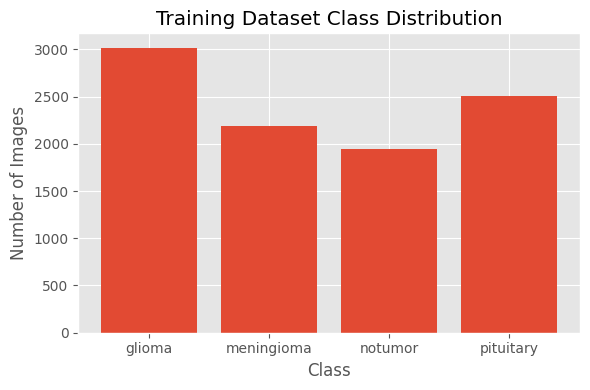

In [ ]:
# class distribution

classes = list(train_counts.keys())
counts = list(train_counts.values())

plt.figure(figsize=(6, 4))

plt.bar(classes, counts)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

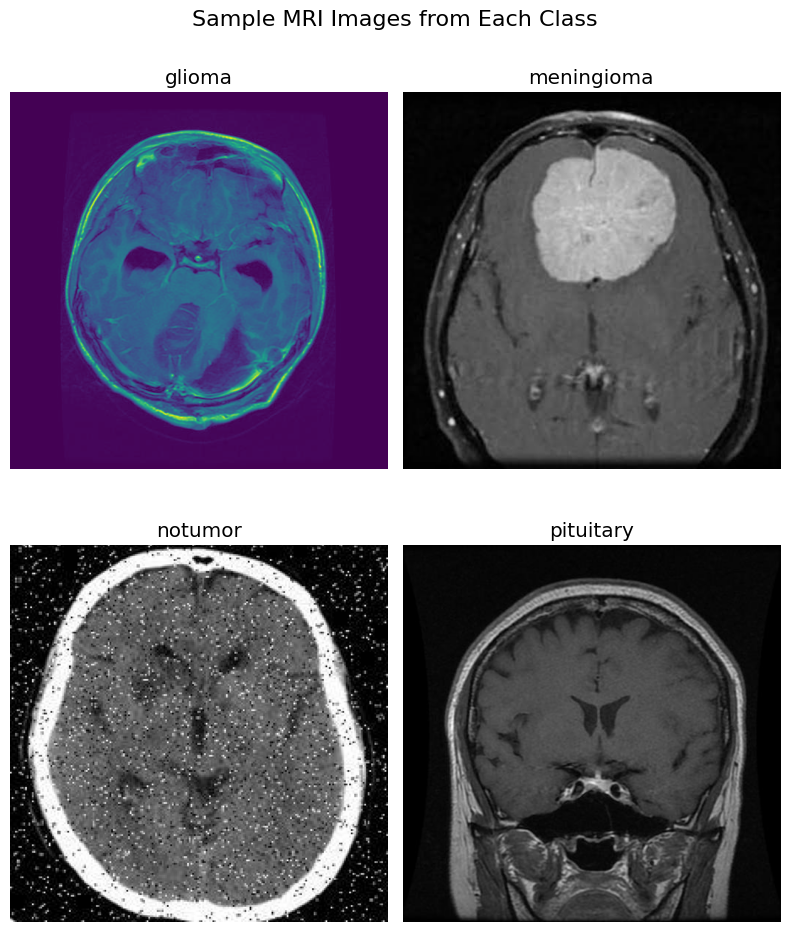

In [ ]:
# display sample MRI images

classes = sorted(os.listdir(TRAIN_DIR))

plt.figure(figsize=(8, 10))

for i, class_name in enumerate(classes):

    class_path = os.path.join(TRAIN_DIR, class_name)

    # Get image files
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(VALID_EXTENSIONS)
    ]

    # Select first image
    image_path = os.path.join(class_path, image_files[100])

    # Open image
    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Sample MRI Images from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# check the image dimensions

image_sizes = []

for class_name in classes:

    class_path = os.path.join(TRAIN_DIR, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(VALID_EXTENSIONS)
    ]

    for image_file in image_files:

        image_path = os.path.join(class_path, image_file)

        try:
            image = Image.open(image_path)
            image_sizes.append(image.size)

        except Exception:
            pass

size_counts = Counter(image_sizes)

print("Number of different image sizes:", len(size_counts))
print("\nMost common image sizes:")

for size, count in size_counts.most_common(5):
    print(f"{size}: {count} images")

Number of different image sizes: 425

Most common image sizes:
(512, 512): 4858 images
(224, 224): 3123 images
(225, 225): 200 images
(236, 236): 101 images
(630, 630): 45 images


In [ ]:
# check image channels/modes

image_modes = []

for class_name in classes:

    class_path = os.path.join(TRAIN_DIR, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(VALID_EXTENSIONS)
    ]

    for image_file in image_files:

        image_path = os.path.join(class_path, image_file)

        try:
            image = Image.open(image_path)
            image_modes.append(image.mode)

        except Exception:
            pass

mode_counts = Counter(image_modes)

print("Image channel/mode distribution:")
print(mode_counts)

Image channel/mode distribution:
Counter({'RGB': 7287, 'L': 2357, 'RGBA': 5, 'P': 1})


In [ ]:
# check pixel-value statistics

pixel_values = []

# Sample a limited number of images to keep EDA fast
max_images_per_class = 100

for class_name in classes:

    class_path = os.path.join(TRAIN_DIR, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(VALID_EXTENSIONS)
    ]

    # Take up to 100 images from each class
    image_files = image_files[:max_images_per_class]

    for image_file in image_files:

        image_path = os.path.join(class_path, image_file)

        try:
            image = Image.open(image_path).convert("RGB")
            image_array = np.array(image)

            pixel_values.append(image_array)

        except Exception:
            pass

# Combine sampled images
pixel_values = np.concatenate(
    [img.reshape(-1, 3) for img in pixel_values],
    axis=0
)

print("Pixel statistics")
print("=" * 40)

print("Minimum pixel value :", pixel_values.min())
print("Maximum pixel value :", pixel_values.max())
print("Mean pixel value    :", np.round(pixel_values.mean(),2))
print("Standard deviation  :", np.round(pixel_values.std(),2))

Pixel statistics
Minimum pixel value : 0
Maximum pixel value : 255
Mean pixel value    : 41.39
Standard deviation  : 45.03


In [ ]:
# image format analysis

format_counts = Counter()

for dataset_name, dataset_dir in [
    ("Train", TRAIN_DIR),
    ("Test", TEST_DIR)
]:

    for class_name in sorted(os.listdir(dataset_dir)):

        class_path = os.path.join(dataset_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for image_file in os.listdir(class_path):

            if image_file.lower().endswith(VALID_EXTENSIONS):

                extension = os.path.splitext(image_file)[1].lower()
                format_counts[extension] += 1

print("Image file formats")
print("=" * 20)

for extension, count in format_counts.items():
    print(f"{extension:6s}: {count}")

Image file formats
.jpg  : 12060
.jpeg : 4
